In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

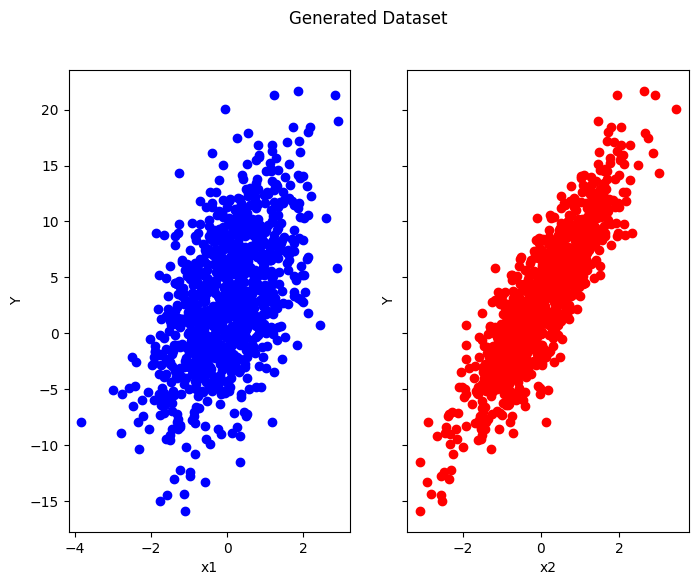

In [6]:
torch.manual_seed(42)

#Generate a syntathetic dataset
num_samples = 1000
x = torch.randn(num_samples, 2) 
true_weights = torch.tensor([3, 5], dtype=torch.float32)
true_bias = torch.tensor([3], dtype=torch.float32)
y = x @ true_weights + true_bias


#visualize the dataset
fig, ax = plt.subplots(1,2 , sharey= True, figsize=(8, 6))
ax[0].scatter(x[:, 0], y, c='blue', label='Data points')
ax[1].scatter(x[:, 1], y, c='red', label='Data points')

ax[0].set_xlabel('x1'); ax[0].set_ylabel('Y')
ax[1].set_xlabel('x2'); ax[1].set_ylabel('Y')
plt.suptitle("Generated Dataset")
plt.show()


In [9]:
class LinearRegression(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_size, output_size) # 2 input features, 1 output

    def forward(self, x):
        return self.linear(x)
    
input_size = x.shape[1]
output_size = 1
model = LinearRegression(input_size, output_size)


In [11]:
weight = torch.randn(1, input_size, requires_grad= True)
bias = torch.rand(1, requires_grad=True)

model.linear.weight = nn.Parameter(weight)
model.linear.bias = nn.Parameter(bias)

print('Initial weights:', model.linear.weight)
print('Initial bias:', model.linear.bias)


Initial weights: Parameter containing:
tensor([[-0.3239,  0.5574]], requires_grad=True)
Initial bias: Parameter containing:
tensor([0.5710], requires_grad=True)


In [12]:
# Forward pass to generate predictions
y_p = model(x)
print("Initial predictions:\n", y_p[:5])

Initial predictions:
 tensor([[ 0.7760],
        [-0.8944],
        [-0.3369],
        [-0.3095],
        [ 1.7338]], grad_fn=<SliceBackward0>)


In [13]:
def Mean_Squared_Error(prediction, actual):
    error = (actual - prediction) ** 2
    return error.mean()

# Calculate initial loss
initial_loss = Mean_Squared_Error(y_p, y)
print("Initial MSE loss:", initial_loss.item())

Initial MSE loss: 41.90708923339844


Epoch [100/1000], Weight: [[-0.06761929  0.08869881]], Bias: [2.7138822], Loss: 35.5803
Epoch [200/1000], Weight: [[-0.01286591  0.01401526]], Bias: [3.002096], Loss: 35.4569
Epoch [300/1000], Weight: [[-0.00232171  0.00220447]], Bias: [3.0410187], Loss: 35.4545
Epoch [400/1000], Weight: [[-0.00040498  0.00034574]], Bias: [3.0462985], Loss: 35.4544
Epoch [500/1000], Weight: [[-6.901197e-05  5.413510e-05]], Bias: [3.0470185], Loss: 35.4544
Epoch [600/1000], Weight: [[-1.1566645e-05  8.4714002e-06]], Bias: [3.047117], Loss: 35.4544
Epoch [700/1000], Weight: [[-1.9369068e-06  1.3527992e-06]], Bias: [3.0471272], Loss: 35.4544
Epoch [800/1000], Weight: [[-3.9734670e-07  2.9965358e-07]], Bias: [3.0471272], Loss: 35.4544
Epoch [900/1000], Weight: [[-1.3851839e-07  1.3088820e-07]], Bias: [3.0471272], Loss: 35.4544
Epoch [1000/1000], Weight: [[-9.1647010e-08  1.0027077e-07]], Bias: [3.0471272], Loss: 35.4544


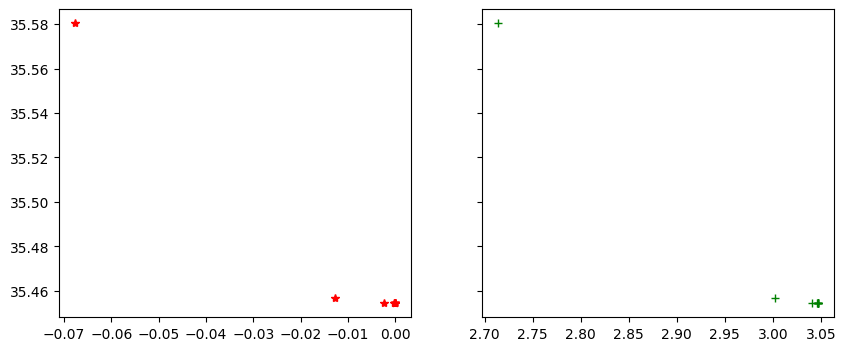

In [14]:
num_epochs = 1000
learning_rate = 0.01
losses = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for epoch in range(num_epochs):
    y_pred = model(x)
    loss = Mean_Squared_Error(y_pred, y)
    losses.append(loss.item())

    # Backward pass
    loss.backward()

    with torch.no_grad():
        # Update weights and bias directly without replacing them
        model.linear.weight -= learning_rate * model.linear.weight.grad
        model.linear.bias -= learning_rate * model.linear.bias.grad

        # Zero gradients for next iteration
        model.linear.weight.grad.zero_()
        model.linear.bias.grad.zero_()

    if (epoch + 1) % 100 == 0:
        # Plot first weight component vs loss
        ax1.plot([model.linear.weight[0, 0].item()], [loss.item()], 'r*')
        # Plot bias vs loss
        ax2.plot([model.linear.bias.item()], [loss.item()], 'g+')

        print(f"Epoch [{epoch+1}/{num_epochs}], "
            f"Weight: {model.linear.weight.data.numpy()}, "
            f"Bias: {model.linear.bias.data.numpy()}, "
            f"Loss: {loss.item():.4f}")

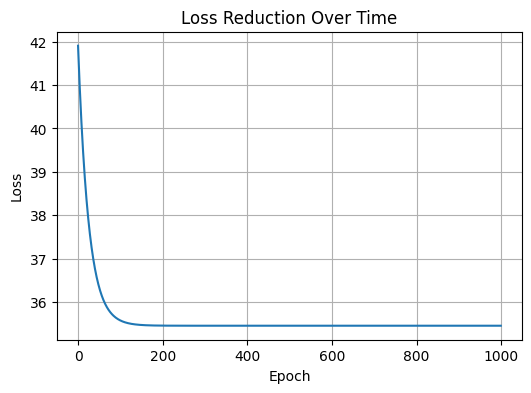

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Reduction Over Time')
plt.grid(True)
plt.show()